In [3]:
import os

print(
    os.listdir(
        r"C:\Users\91991\Desktop\internships\AMDOX\notebooks"
    )
)

['.ipynb_checkpoints', '01_data_loading_cleaning.ipynb', '02_rfm_feature_engineering.ipynb', '03_customer_segmentation.ipynb', '04_m5_data_preprocessing.ipynb', '05_prophet_forecasting.ipynb', '06_xgboost_forecasting.ipynb', '07_inventory_optimization.ipynb', '08_recommendation_system.ipynb', '09_churn_prediction.ipynb', '10_abc_xyz_inventory_analysis.ipynb', '11_xgboost_explainability.ipynb', '12_sales_product_analytics.ipynb']


In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option(
    "display.max_columns",
    None
)

In [5]:
df = pd.read_csv(
    r"C:\Users\91991\Desktop\internships\AMDOX\data\processed\clean_online_retail.csv"
)

print(df.shape)

df.head()

(400916, 9)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


In [6]:
print(df.columns)

print()

print(df.isnull().sum())

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country', 'Revenue'],
      dtype='object')

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
Revenue        0
dtype: int64


In [7]:
total_revenue = df["Revenue"].sum()

total_orders = df["Invoice"].nunique()

total_customers = df["Customer ID"].nunique()

total_products = df["StockCode"].nunique()

average_order_value = (

    total_revenue

    / total_orders
)

print("Total Revenue :", round(total_revenue, 2))

print("Total Orders :", total_orders)

print("Total Customers :", total_customers)

print("Total Products :", total_products)

print(
    "Average Order Value :",
    round(average_order_value, 2)
)

Total Revenue : 8798233.74
Total Orders : 19213
Total Customers : 4312
Total Products : 4017
Average Order Value : 457.93


In [8]:
df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"]
)

df["YearMonth"] = (

    df["InvoiceDate"]

    .dt.to_period("M")
)

In [9]:
monthly_revenue = (

    df.groupby(
        "YearMonth"
    )["Revenue"]

    .sum()

    .reset_index()
)

monthly_revenue

,YearMonth,Revenue
0,2009-12,683504.010
1,2010-01,555802.672
2,2010-02,504558.956
3,2010-03,696978.471
4,2010-04,591982.002
5,2010-05,597833.380
6,2010-06,636371.130
7,2010-07,589736.170
8,2010-08,602224.600
9,2010-09,829013.951


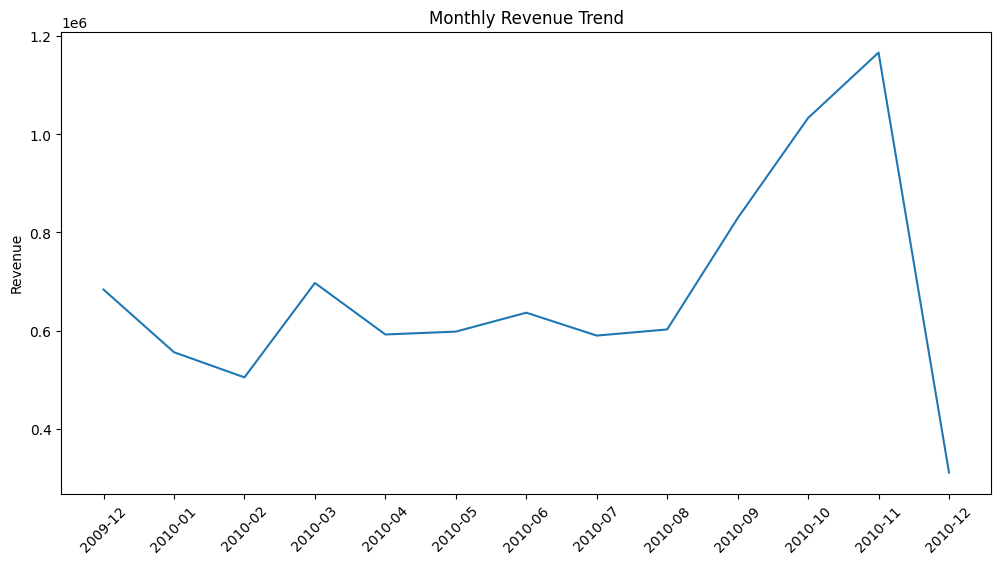

In [10]:
plt.figure(figsize=(12,6))

plt.plot(

    monthly_revenue["YearMonth"].astype(str),

    monthly_revenue["Revenue"]
)

plt.xticks(rotation=45)

plt.title(
    "Monthly Revenue Trend"
)

plt.ylabel(
    "Revenue"
)

plt.show()

In [11]:
country_revenue = (

    df.groupby(
        "Country"
    )["Revenue"]

    .sum()

    .sort_values(
        ascending=False
    )

    .head(10)

    .reset_index()
)

country_revenue

,Country,Revenue
0,United Kingdom,7381644.433
1,EIRE,356041.860
2,Netherlands,268784.350
3,Germany,202025.391
4,France,146107.070
5,Sweden,53147.990
6,Denmark,50906.850
7,Spain,47568.650
8,Switzerland,43921.390
9,Australia,31446.800


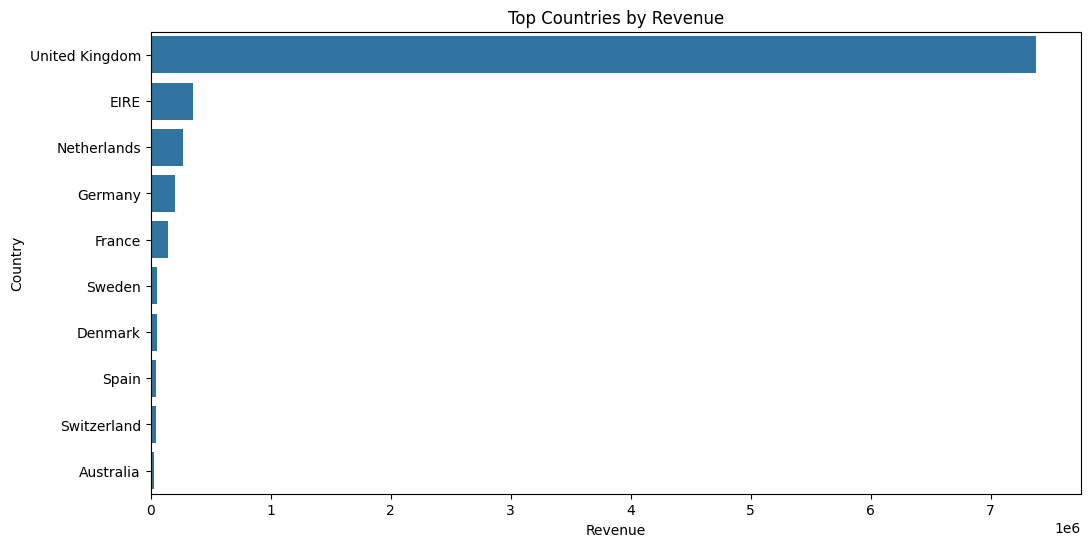

In [12]:
plt.figure(figsize=(12,6))

sns.barplot(

    data=country_revenue,

    x="Revenue",

    y="Country"
)

plt.title(
    "Top Countries by Revenue"
)

plt.show()

In [13]:
top_products = (

    df.groupby(
        "Description"
    )["Revenue"]

    .sum()

    .sort_values(
        ascending=False
    )

    .head(10)

    .reset_index()
)

top_products

,Description,Revenue
0,WHITE HANGING HEART T-LIGHT HOLDER,151339.16
1,REGENCY CAKESTAND 3 TIER,143727.60
2,Manual,98531.99
3,ASSORTED COLOUR BIRD ORNAMENT,70291.03
4,JUMBO BAG RED RETROSPOT,51644.25
5,POSTAGE,48741.08
6,ROTATING SILVER ANGELS T-LIGHT HLDR,40156.05
7,PAPER CHAIN KIT 50'S CHRISTMAS,36871.55
8,PARTY BUNTING,35017.30
9,EDWARDIAN PARASOL NATURAL,34044.75


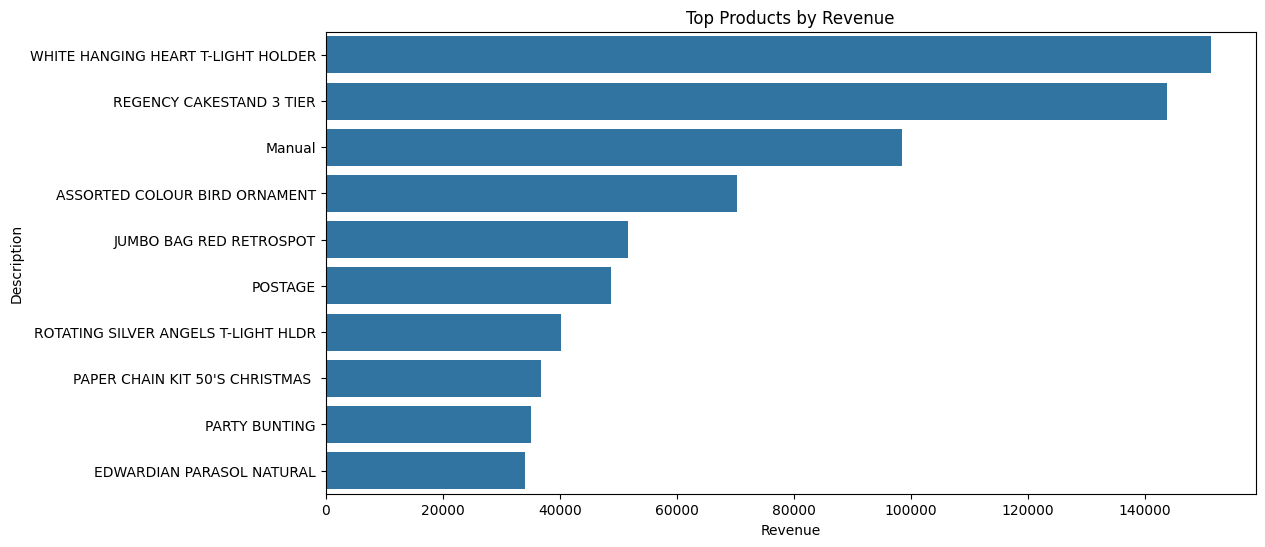

In [14]:
plt.figure(figsize=(12,6))

sns.barplot(

    data=top_products,

    x="Revenue",

    y="Description"
)

plt.title(
    "Top Products by Revenue"
)

plt.show()

In [15]:
top_quantity = (

    df.groupby(
        "Description"
    )["Quantity"]

    .sum()

    .sort_values(
        ascending=False
    )

    .head(10)

    .reset_index()
)

top_quantity

,Description,Quantity
0,WHITE HANGING HEART T-LIGHT HOLDER,56814
1,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54610
2,BROCADE RING PURSE,48166
3,PACK OF 72 RETRO SPOT CAKE CASES,45129
4,ASSORTED COLOUR BIRD ORNAMENT,44431
5,60 TEATIME FAIRY CAKE CASES,35656
6,PACK OF 60 PINK PAISLEY CAKE CASES,30871
7,JUMBO BAG RED RETROSPOT,29519
8,SMALL POPCORN HOLDER,25703
9,BLACK AND WHITE PAISLEY FLOWER MUG,25685


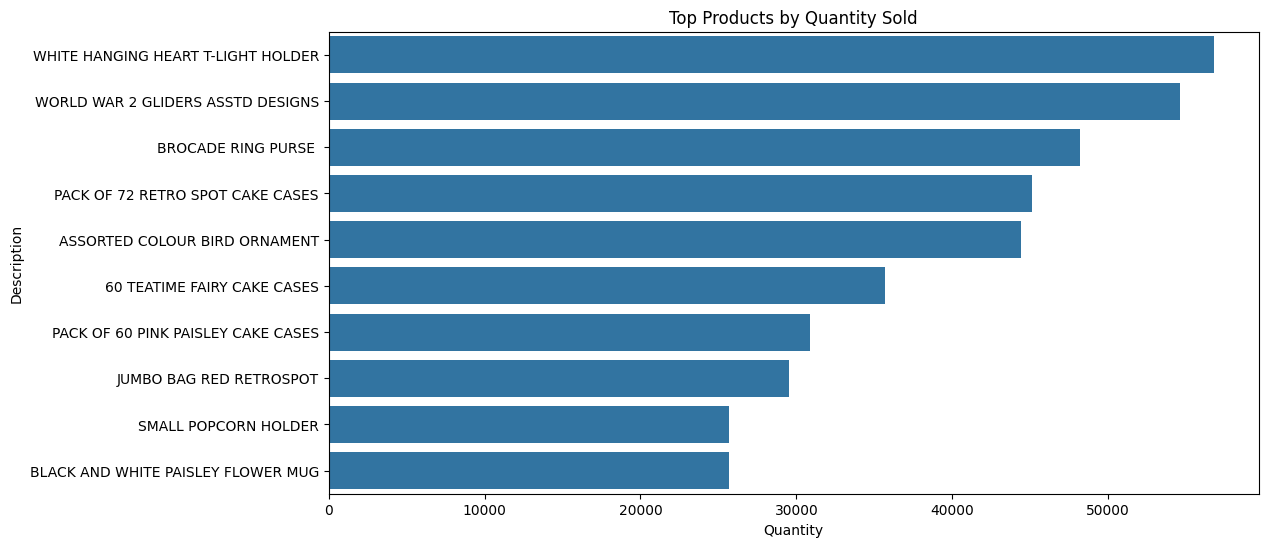

In [16]:
plt.figure(figsize=(12,6))

sns.barplot(

    data=top_quantity,

    x="Quantity",

    y="Description"
)

plt.title(
    "Top Products by Quantity Sold"
)

plt.show()

In [17]:
monthly_sales = (

    df.groupby(
        df["InvoiceDate"].dt.month
    )["Revenue"]

    .sum()

    .reset_index()
)

monthly_sales.columns = [

    "Month",

    "Revenue"
]

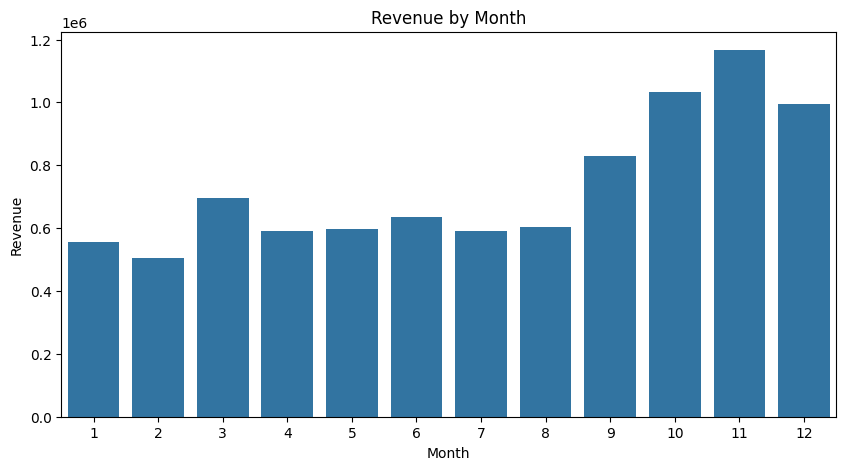

In [18]:
plt.figure(figsize=(10,5))

sns.barplot(

    data=monthly_sales,

    x="Month",

    y="Revenue"
)

plt.title(
    "Revenue by Month"
)

plt.show()

In [19]:
df["Weekday"] = (

    df["InvoiceDate"]

    .dt.day_name()
)

weekday_sales = (

    df.groupby(
        "Weekday"
    )["Revenue"]

    .sum()

    .reset_index()
)

weekday_sales

,Weekday,Revenue
0,Friday,1269250.992
1,Monday,1445606.495
2,Saturday,9803.050
3,Sunday,1014540.011
4,Thursday,1858159.182
5,Tuesday,1678827.301
6,Wednesday,1522046.713


In [20]:
order = [

    "Monday",

    "Tuesday",

    "Wednesday",

    "Thursday",

    "Friday",

    "Saturday",

    "Sunday"
]

weekday_sales["Weekday"] = pd.Categorical(

    weekday_sales["Weekday"],

    categories=order,

    ordered=True
)

weekday_sales = weekday_sales.sort_values(
    "Weekday"
)

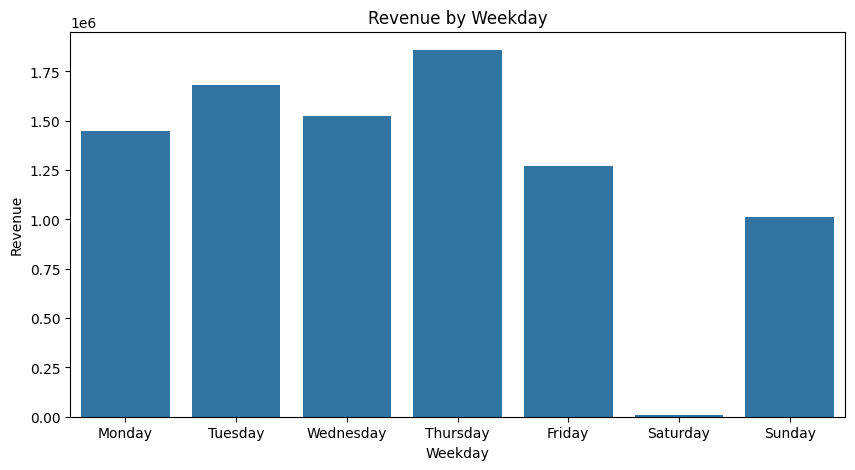

In [21]:
plt.figure(figsize=(10,5))

sns.barplot(

    data=weekday_sales,

    x="Weekday",

    y="Revenue"
)

plt.title(
    "Revenue by Weekday"
)

plt.show()

In [22]:
orders_per_day = (

    df.groupby(
        df["InvoiceDate"].dt.date
    )["Invoice"]

    .nunique()

    .reset_index()
)

orders_per_day.columns = [

    "Date",

    "Orders"
]

orders_per_day.head()

,Date,Orders
0,2009-12-01,98
1,2009-12-02,110
2,2009-12-03,122
3,2009-12-04,80
4,2009-12-05,30


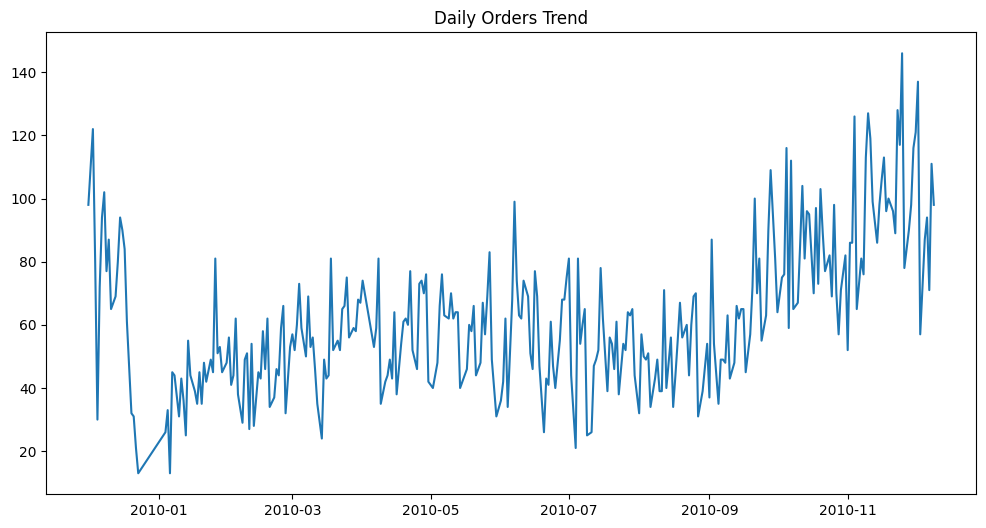

In [23]:
plt.figure(figsize=(12,6))

plt.plot(

    orders_per_day["Date"],

    orders_per_day["Orders"]
)

plt.title(
    "Daily Orders Trend"
)

plt.show()

In [25]:
monthly_revenue.to_csv(
    r"C:\Users\91991\Desktop\internships\AMDOX\data\processed\monthly_revenue.csv",
    index=False
)

weekday_sales.to_csv(
    r"C:\Users\91991\Desktop\internships\AMDOX\data\processed\weekday_sales.csv",
    index=False
)

country_revenue.to_csv(
    r"C:\Users\91991\Desktop\internships\AMDOX\data\processed\country_revenue.csv",
    index=False
)

top_products.to_csv(
    r"C:\Users\91991\Desktop\internships\AMDOX\data\processed\top_products.csv",
    index=False
)

top_quantity.to_csv(
    r"C:\Users\91991\Desktop\internships\AMDOX\data\processed\top_quantity_products.csv",
    index=False
)

orders_per_day.to_csv(
    r"C:\Users\91991\Desktop\internships\AMDOX\data\processed\orders_per_day.csv",
    index=False
)

print("Sales analytics files saved")

Sales analytics files saved
